In [2]:
# RAY-IMAGE — Kaggle bootstrap
# Purpose:
#   1. Detect Kaggle GPU environment
#   2. Clone the canonical GitHub main branch
#   3. Verify the exact repository revision
#   4. Verify the RAY-IMAGE package imports

import os
import sys
import subprocess
from pathlib import Path

REPO_URL = "https://github.com/Rishidev-20thcenturey/anime-ai-companion.git"
REPO_DIR = Path("/kaggle/working/anime-ai-companion")

# ------------------------------------------------------------
# 1. GPU / environment
# ------------------------------------------------------------
print("=== GPU / ENVIRONMENT ===")

subprocess.run(["nvidia-smi"], check=False)

import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)

if torch.cuda.is_available():
    print("GPU count:", torch.cuda.device_count())
    for i in range(torch.cuda.device_count()):
        print(f"GPU {i}:", torch.cuda.get_device_name(i))
        props = torch.cuda.get_device_properties(i)
        print(f"  VRAM: {props.total_memory / 1024**3:.2f} GB")

# ------------------------------------------------------------
# 2. Clone canonical MAIN
# ------------------------------------------------------------
print("\n=== GITHUB ===")

if REPO_DIR.exists():
    print("Existing repo found. Removing stale checkout...")
    subprocess.run(["rm", "-rf", str(REPO_DIR)], check=True)

subprocess.run(
    ["git", "clone", "--branch", "main", "--single-branch", REPO_URL, str(REPO_DIR)],
    check=True,
)

os.chdir(REPO_DIR)

# ------------------------------------------------------------
# 3. Verify exact revision
# ------------------------------------------------------------
commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()

branch = subprocess.check_output(
    ["git", "branch", "--show-current"],
    text=True
).strip()

print("Branch:", branch)
print("Commit:", commit)

assert branch == "main", f"Expected main, got {branch}"

# ------------------------------------------------------------
# 4. Verify important RAY files
# ------------------------------------------------------------
required_files = [
    "ray_image/dit.py",
    "ray_image/probe_n5_shape.py",
    "ray_image/probe_vae_latents.py",
]

print("\n=== REQUIRED FILES ===")

for rel in required_files:
    path = REPO_DIR / rel
    print(f"{rel}: {'OK' if path.exists() else 'MISSING'}")
    assert path.exists(), f"Missing required file: {rel}"

# ------------------------------------------------------------
# 5. Import test
# ------------------------------------------------------------
print("\n=== IMPORT TEST ===")

sys.path.insert(0, str(REPO_DIR))

import ray_image

print("ray_image import: OK")

print("\n=== BOOTSTRAP COMPLETE ===")
print("RAY-IMAGE is running from GitHub MAIN.")
print("Commit:", commit)

=== GPU / ENVIRONMENT ===
Wed Sep  9 16:42:34 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   55C    P8             12W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+---------------------

Cloning into '/kaggle/working/anime-ai-companion'...


Branch: main
Commit: 22835f9c2162a40c0d6fe0c8b7aa981662c2b8b9

=== REQUIRED FILES ===
ray_image/dit.py: OK
ray_image/probe_n5_shape.py: OK
ray_image/probe_vae_latents.py: OK

=== IMPORT TEST ===
ray_image import: OK

=== BOOTSTRAP COMPLETE ===
RAY-IMAGE is running from GitHub MAIN.
Commit: 22835f9c2162a40c0d6fe0c8b7aa981662c2b8b9


In [3]:
import os
import subprocess

# First move OUT of any deleted/stale directory
os.chdir("/kaggle/working")

REPO_DIR = "/kaggle/working/anime-ai-companion"
REPO_URL = "https://github.com/Rishidev-20thcenturey/anime-ai-companion.git"

# Remove old checkout safely
subprocess.run(["rm", "-rf", REPO_DIR], check=True)

# Clone canonical main branch
subprocess.run([
    "git", "clone",
    "--branch", "main",
    "--single-branch",
    REPO_URL,
    REPO_DIR
], check=True)

os.chdir(REPO_DIR)

print("=== GITHUB CONNECTED ===")
print("Directory:", os.getcwd())

print("\n=== COMMIT ===")
subprocess.run(["git", "rev-parse", "--short", "HEAD"])

print("\n=== BRANCH ===")
subprocess.run(["git", "branch", "--show-current"])

print("\n=== RECENT COMMITS ===")
subprocess.run(["git", "log", "-5", "--oneline", "--decorate"])

Cloning into '/kaggle/working/anime-ai-companion'...


=== GITHUB CONNECTED ===
Directory: /kaggle/working/anime-ai-companion

=== COMMIT ===
22835f9

=== BRANCH ===
main

=== RECENT COMMITS ===
22835f9 (HEAD -> main, origin/main, origin/HEAD) Update README.md
d2c0f63 Merge pull request #1 from Rishidev-20thcenturey/arena/01a07cdc-anime-ai-companion
2dd7926 Fix N5.1 report path in Colab notebook
346ceaa Add standalone RAY-IMAGE N5.1 Colab diagnostic notebook
0f26dd0 N5.1: shape-geometry diagnostic (evaluator calibration audit)


CompletedProcess(args=['git', 'log', '-5', '--oneline', '--decorate'], returncode=0)

In [4]:
from pathlib import Path

ROOT = Path("/kaggle/working/anime-ai-companion")

files = [
    "ray_image/probe_n5_shape.py",
    "ray_image/dit.py",
    "ray_image/probe_vae_latents.py",
]

print("=== CORRECTED REQUIRED FILE CHECK ===")

for rel in files:
    p = ROOT / rel
    print(f"{rel}: {'OK' if p.exists() else 'MISSING'}")

# Verify the N5 cross-gate implementation
dit_text = (ROOT / "ray_image/dit.py").read_text()

print("\n=== N5 CROSS-GATE CHECK ===")
print("cross_gate parameter:",
      "OK" if "self.cross_gate" in dit_text else "MISSING")
print("gated cross-attention:",
      "OK" if "self.cross_gate * cross" in dit_text else "MISSING")

print("\n=== DONE ===")

=== CORRECTED REQUIRED FILE CHECK ===
ray_image/probe_n5_shape.py: OK
ray_image/dit.py: OK
ray_image/probe_vae_latents.py: OK

=== N5 CROSS-GATE CHECK ===
cross_gate parameter: OK
gated cross-attention: OK

=== DONE ===


In [5]:
from pathlib import Path

ROOT = Path("/kaggle/working/anime-ai-companion")

print("=== PROJECT STRUCTURE ===")

for folder in ["ray_image", "configs", "scripts", "notebooks", "data"]:
    p = ROOT / folder
    print(f"\n[{folder}]")
    if p.exists():
        for x in sorted(p.rglob("*")):
            if x.is_file():
                print(" ", x.relative_to(ROOT))
    else:
        print("  (not present)")

print("\n=== CHECKPOINT SEARCH ===")

# Search repo + Kaggle working area for checkpoint-like files
for base in [ROOT, Path("/kaggle/working")]:
    print(f"\nSearching: {base}")
    for pattern in ["*.pt", "*.pth", "*.ckpt", "*.safetensors"]:
        for p in sorted(base.glob(pattern))[:50]:
            print(" ", p)

print("\n=== TRAINING ENTRY POINTS ===")

for p in sorted(ROOT.rglob("*.py")):
    name = p.name.lower()
    if "train" in name or "smoke" in name:
        print(" ", p.relative_to(ROOT))

print("\n=== AUDIT COMPLETE ===")

=== PROJECT STRUCTURE ===

[ray_image]
  ray_image/__init__.py
  ray_image/config.py
  ray_image/dataset.py
  ray_image/dit.py
  ray_image/evaluate.py
  ray_image/flow.py
  ray_image/generate.py
  ray_image/n4_smoke.py
  ray_image/n5_smoke.py
  ray_image/probe_latent_separability.py
  ray_image/probe_n5_shape.py
  ray_image/probe_smoke.py
  ray_image/probe_text_conditioning.py
  ray_image/probe_text_smoke.py
  ray_image/probe_vae_latents.py
  ray_image/text_encoder.py
  ray_image/toy.py
  ray_image/train.py
  ray_image/train_generator.py
  ray_image/train_n5.py
  ray_image/train_smoke.py
  ray_image/train_vae.py
  ray_image/utils.py
  ray_image/vae.py
  ray_image/whiten.py
  ray_image/whiten_smoke.py

[configs]
  (not present)

[scripts]
  (not present)

[notebooks]
  notebooks/RAY_IMAGE_Colab.ipynb
  notebooks/RAY_IMAGE_N1_NOW_Colab.ipynb
  notebooks/RAY_IMAGE_N2_ONE_CLICK_Colab.ipynb
  notebooks/RAY_IMAGE_N4_STANDALONE_Colab.ipynb
  notebooks/RAY_IMAGE_N5_1_STANDALONE_Colab.ipynb
  n

In [6]:
from pathlib import Path

ROOT = Path("/kaggle/working/anime-ai-companion")

print("=== TRAIN_N5.PY ===")
p = ROOT / "ray_image/train_n5.py"
text = p.read_text()
print(text)

print("\n=== N5 NOTEBOOK CHECKPOINT REFERENCES ===")
nb = ROOT / "notebooks/RAY_IMAGE_N5_STANDALONE_Colab.ipynb"
nb_text = nb.read_text()

for line in nb_text.splitlines():
    low = line.lower()
    if any(k in low for k in [
        "checkpoint",
        ".pt",
        ".pth",
        "google drive",
        "drive.mount",
        "dataset",
        "train_n5",
        "resume",
    ]):
        print(line[:500])

print("\n=== END INSPECTION ===")

=== TRAIN_N5.PY ===
"""N5: train the gated-cross-attention generator, warm-started from the N2 baseline.

Single controlled architecture change (N5):
  add a per-block learnable scalar gate to the token-level text cross-attention
  residual in the DiT (x = x + gate * cross), gate init = 1.0 so the model
  starts mathematically identical to N2 before training.

This entry point does NOT train from scratch:
  - loads the N2 generator checkpoint (vae, text encoder, dit, vocab, whiten),
  - reconstructs the DiT WITH the new gates (dit_cross_gate=True),
  - loads every compatible N2 weight (strict=False), leaving only the NEW gate
    parameters at their init value 1.0,
  - then trains the text encoder + DiT on the same flow objective / whitened
    latent convention / budget as N2.

No VAE / dataset / tokenizer / flow / sampler / resolution / model-size change.
CFG is NOT added. Nothing here silently launches training -- it must be invoked.
"""
import argparse
from pathlib import Path

imp

In [7]:
print("=== TRAIN_N5 KEY LINES ===")

for i, line in enumerate(text.splitlines(), 1):
    low = line.lower()
    if any(k in low for k in [
        "checkpoint",
        "resume",
        "save",
        "dataset",
        "epochs",
        "batch",
        "lr",
        "output",
        "argparse",
    ]):
        print(f"{i}: {line}")

print("\n=== NOTEBOOK KEY REFERENCES ===")

for line in nb_text.splitlines():
    low = line.lower()
    if any(k in low for k in [
        "checkpoint",
        ".pt",
        "drive",
        "dataset",
        "train_n5",
        "resume",
    ]):
        print(line[:600])

=== TRAIN_N5 KEY LINES ===
9:   - loads the N2 generator checkpoint (vae, text encoder, dit, vocab, whiten),
16: No VAE / dataset / tokenizer / flow / sampler / resolution / model-size change.
19: import argparse
29: from .dataset import RAYCaptionDataset, encode_text
31: from .utils import build_models, load_checkpoint, save_checkpoint, set_seed
35: def config_from_checkpoint(raw_cfg: dict) -> RAYConfig:
42: def build_n5_from_n2(n2_checkpoint: str, device, cfg=None):
47:                    in the N2 checkpoint (the newly initialized gates).
49:     Raises if the N2 checkpoint cannot be read.
51:     n2 = load_checkpoint(n2_checkpoint, device)
53:         cfg = config_from_checkpoint(n2.get("config", {}))
89: def train(cfg, vocab, vae, text_encoder, dit, whiten, manifest, steps, batch_size,
90:           lr, save, seed, device):
92:     dataset = RAYCaptionDataset(manifest, cfg.image_size)
93:     if len(dataset) < batch_size:
94:         raise ValueError(f"dataset has {len(dataset)} s

In [8]:
from pathlib import Path

print("=== KAGGLE INPUT SOURCES ===")

input_root = Path("/kaggle/input")

if input_root.exists():
    entries = sorted(input_root.iterdir())
    if entries:
        for p in entries:
            print(p)
    else:
        print("No attached Kaggle datasets yet.")
else:
    print("/kaggle/input does not exist.")

print("\n=== SEARCHING FOR N2 CHECKPOINT ===")

matches = []

for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
    if base.exists():
        for pattern in [
            "ray_image_v0_2_2_whiten.pt",
            "ray_image_v0_2_whiten.pt",
            "*.pt",
            "*.pth",
        ]:
            for p in base.rglob(pattern):
                if p.is_file():
                    matches.append(p)

seen = set()
for p in matches:
    if str(p) not in seen:
        print(p)
        seen.add(str(p))

print("\n=== SEARCHING FOR TOY MANIFEST ===")

for base in [Path("/kaggle/input"), Path("/kaggle/working")]:
    if base.exists():
        for p in base.rglob("manifest.json"):
            print(p)

print("\n=== DONE ===")

=== KAGGLE INPUT SOURCES ===
No attached Kaggle datasets yet.

=== SEARCHING FOR N2 CHECKPOINT ===

=== SEARCHING FOR TOY MANIFEST ===

=== DONE ===


In [9]:
from pathlib import Path

root = Path("/kaggle/input")

print("=== N2 CHECKPOINT INPUT ===")

for p in root.rglob("*"):
    if p.is_file():
        print(p)

print("=== DONE ===")

=== N2 CHECKPOINT INPUT ===
=== DONE ===


In [1]:
from pathlib import Path

print("=== KAGGLE INPUT ===")
for p in Path("/kaggle/input").rglob("*"):
    if p.is_file():
        print(p)
print("=== DONE ===")

=== KAGGLE INPUT ===
=== DONE ===


In [2]:
from pathlib import Path

root = Path("/kaggle/input")

print("=== TOP LEVEL INPUT ===")
for p in root.iterdir():
    print(p, "DIR" if p.is_dir() else f"FILE {p.stat().st_size/(1024**2):.2f} MB")

print("=== DONE ===")

=== TOP LEVEL INPUT ===
/kaggle/input/datasets DIR
=== DONE ===


In [4]:
from pathlib import Path

root = Path("/kaggle/input/datasets")

print("=== DATASET CONTENTS ===")
for p in root.iterdir():
    print(p, "DIR" if p.is_dir() else f"FILE {p.stat().st_size/(1024**2):.2f} MB")
print("=== DONE ===")

=== DATASET CONTENTS ===
/kaggle/input/datasets/rishirajdev DIR
=== DONE ===


In [6]:
from pathlib import Path

root = Path("/kaggle/input/datasets/rishirajdev")

print("=== DATASET FILES ===")
for p in root.iterdir():
    print(p, "DIR" if p.is_dir() else f"FILE {p.stat().st_size/(1024**2):.2f} MB")
print("=== DONE ===")

=== DATASET FILES ===
/kaggle/input/datasets/rishirajdev/dataset DIR
=== DONE ===


In [7]:
from pathlib import Path

root = Path("/kaggle/input/datasets/rishirajdev/dataset")

print("=== CHECKPOINT FILES ===")
for name in ["ray_image_v0_2_whiten.pt", "ray_image_v0_3_n5.pt",
             "ray_image_vO_2_whiten.pt"]:
    p = root / name
    print(f"{name}: {'FOUND' if p.exists() else 'NOT FOUND'}")

print("=== DONE ===")

=== CHECKPOINT FILES ===
ray_image_v0_2_whiten.pt: FOUND
ray_image_v0_3_n5.pt: NOT FOUND
ray_image_vO_2_whiten.pt: NOT FOUND
=== DONE ===


In [8]:
import torch

ckpt_path = "/kaggle/input/datasets/rishirajdev/dataset/ray_image_v0_2_whiten.pt"

ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)

print("=== N2 CHECKPOINT ===")
print("Top-level keys:")
print(list(ckpt.keys()))

print("\nStage:", ckpt.get("stage"))
print("Config type:", type(ckpt.get("config")).__name__)
print("Has VAE:", "vae" in ckpt)
print("Has text_encoder:", "text_encoder" in ckpt)
print("Has DiT:", "dit" in ckpt)
print("Has vocab:", "vocab" in ckpt)
print("Has whiten:", "whiten" in ckpt)

print("=== DONE ===")

=== N2 CHECKPOINT ===
Top-level keys:
['config', 'step', 'vocab', 'vae', 'text_encoder', 'dit', 'stage', 'whiten']

Stage: generator_v0.2
Config type: dict
Has VAE: True
Has text_encoder: True
Has DiT: True
Has vocab: True
Has whiten: True
=== DONE ===


In [10]:
print("=== N2 CONFIG ===")
for k, v in ckpt["config"].items():
    print(f"{k}: {v}")
print("=== DONE ===")

=== N2 CONFIG ===
image_size: 64
latent_channels: 4
vae_base: 32
model_dim: 256
depth: 6
heads: 4
patch_size: 2
text_dim: 256
vocab_size: 8192
max_tokens: 64
=== DONE ===


In [11]:
print("=== N2 WHITEN ===")
w = ckpt["whiten"]

print("Type:", type(w).__name__)

if isinstance(w, dict):
    print("Keys:", list(w.keys()))
    for k, v in w.items():
        print(f"{k}: {v}")
else:
    print(w)

print("=== DONE ===")

=== N2 WHITEN ===
Type: dict
Keys: ['mean', 'std']
mean: [1.1806689500808716, -1.624031901359558, 1.9258253574371338, 0.9893305897712708]
std: [1.4000296592712402, 1.7778288125991821, 2.225714921951294, 1.465827465057373]
=== DONE ===


In [12]:
import sys
sys.path.insert(0, "/kaggle/working/anime-ai-companion")

from ray_image.train_n5 import build_n5_from_n2

device = "cuda"

n2_path = "/kaggle/input/datasets/rishirajdev/dataset/ray_image_v0_2_whiten.pt"

print("=== N5 WARM-START TEST ===")

try:
    model_parts = build_n5_from_n2(n2_path, device=device)
    print("N5 BUILD: SUCCESS")
    print("Returned keys:", list(model_parts.keys()) if isinstance(model_parts, dict) else type(model_parts))
except Exception as e:
    print("N5 BUILD: FAILED")
    print(type(e).__name__ + ":", e)

print("=== DONE ===")

ModuleNotFoundError: No module named 'ray_image'

In [13]:
from pathlib import Path

print("=== WORKING DIRECTORY ===")
print(Path.cwd())

print("\n=== WORKING FILES/FOLDERS ===")
for p in Path("/kaggle/working").iterdir():
    print(p)

print("=== DONE ===")

=== WORKING DIRECTORY ===
/kaggle/working

=== WORKING FILES/FOLDERS ===
/kaggle/working/.virtual_documents
=== DONE ===


In [14]:
!git clone https://github.com/Rishidev-20thcenturey/anime-ai-companion.git /kaggle/working/anime-ai-companion

Cloning into '/kaggle/working/anime-ai-companion'...
remote: Enumerating objects: 282, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 282 (delta 4), reused 0 (delta 0), pack-reused 267 (from 1)
Receiving objects: 100% (282/282), 118.67 KiB | 2.58 MiB/s, done.
Resolving deltas: 100% (123/123), done.


In [16]:
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")

print("=== REPO CHECK ===")
print("Exists:", repo.exists())
print("Git:", (repo / ".git").exists())
print("ray_image:", (repo / "ray_image").exists())
print("train_n5.py:", (repo / "ray_image" / "train_n5.py").exists())
print("dit.py:", (repo / "ray_image" / "dit.py").exists())
print("=== DONE ===")

=== REPO CHECK ===
Exists: True
Git: True
ray_image: True
train_n5.py: True
dit.py: True
=== DONE ===


In [22]:
import sys
sys.path.insert(0, "/kaggle/working/anime-ai-companion")

import ray_image

print("=== IMPORT TEST ===")
print("ray_image imported:", ray_image.__file__)

from ray_image.train_n5 import build_n5_from_n2

print("train_n5 import: SUCCESS")
print("=== DONE ===")

ModuleNotFoundError: No module named 'ray_image'

In [24]:
from pathlib import Path
import sys

repo = Path("/kaggle/working/anime-ai-companion")

print("=== PYTHON PATH CHECK ===")
print("Repo exists:", repo.exists())
print("Repo path:", repo.resolve())
print("In sys.path:", str(repo) in sys.path)

print("\n=== ray_image DIRECTORY ===")
ray = repo / "ray_image"
print("Exists:", ray.exists())
print("Is directory:", ray.is_dir())

if ray.exists():
    print("Contents:")
    for p in list(ray.iterdir())[:20]:
        print(" ", p.name)

print("\n=== PACKAGE INIT ===")
print("__init__.py exists:", (ray / "__init__.py").exists())

print("=== DONE ===")

=== PYTHON PATH CHECK ===
Repo exists: True
Repo path: /kaggle/working/anime-ai-companion
In sys.path: True

=== ray_image DIRECTORY ===
Exists: True
Is directory: True
Contents:
  train.py
  text_encoder.py
  probe_latent_separability.py
  train_n5.py
  flow.py
  toy.py
  __init__.py
  evaluate.py
  vae.py
  dataset.py
  utils.py
  probe_vae_latents.py
  train_smoke.py
  dit.py
  generate.py
  probe_n5_shape.py
  n5_smoke.py
  probe_smoke.py
  train_vae.py
  probe_text_smoke.py

=== PACKAGE INIT ===
__init__.py exists: True
=== DONE ===


In [25]:
import sys
import importlib.util

repo = "/kaggle/working/anime-ai-companion"

if repo not in sys.path:
    sys.path.insert(0, repo)

print("=== IMPORT RESOLUTION ===")
print("ray_image spec:", importlib.util.find_spec("ray_image"))
print("train_n5 spec:", importlib.util.find_spec("ray_image.train_n5"))
print("sys.path[0]:", sys.path[0])
print("=== DONE ===")

=== IMPORT RESOLUTION ===
ray_image spec: None


ModuleNotFoundError: No module named 'ray_image'

In [26]:
import importlib.machinery
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
pkg = repo / "ray_image"

print("=== DIRECT PYTHON RESOLUTION ===")
print("repo exists:", repo.exists())
print("ray_image exists:", pkg.exists())
print("ray_image is dir:", pkg.is_dir())
print("ray_image path:", pkg.resolve())

print("\nDirectory listing:")
for p in pkg.iterdir():
    print(repr(p.name))

print("\nPathFinder result:")
print(importlib.machinery.PathFinder.find_spec("ray_image", [str(repo)]))

print("=== DONE ===")

=== DIRECT PYTHON RESOLUTION ===
repo exists: True
ray_image exists: True
ray_image is dir: True
ray_image path: /kaggle/working/anime-ai-companion/ray_image

Directory listing:
'train.py'
'text_encoder.py'
'probe_latent_separability.py'
'train_n5.py'
'flow.py'
'toy.py'
'__init__.py'
'evaluate.py'
'vae.py'
'dataset.py'
'utils.py'
'probe_vae_latents.py'
'train_smoke.py'
'dit.py'
'generate.py'
'probe_n5_shape.py'
'n5_smoke.py'
'probe_smoke.py'
'train_vae.py'
'probe_text_smoke.py'
'config.py'
'n4_smoke.py'
'whiten.py'
'train_generator.py'
'probe_text_conditioning.py'
'whiten_smoke.py'

PathFinder result:
None
=== DONE ===


In [28]:
from pathlib import Path

pkg = Path("/kaggle/working/anime-ai-companion/ray_image")

src = pkg / "__init.py"
dst = pkg / "__init__.py"

print("Before:", src.exists(), "->", dst.exists())

if src.exists() and not dst.exists():
    src.rename(dst)

print("After :", src.exists(), "->", dst.exists())
print("=== DONE ===")

Before: False -> True
After : False -> True
=== DONE ===


In [29]:
import sys

repo = "/kaggle/working/anime-ai-companion"
if repo not in sys.path:
    sys.path.insert(0, repo)

print("=== IMPORT TEST ===")

import ray_image
print("ray_image:", ray_image.__file__)

from ray_image.train_n5 import build_n5_from_n2
print("train_n5: SUCCESS")

print("=== DONE ===")

=== IMPORT TEST ===


ModuleNotFoundError: No module named 'ray_image'

In [31]:
import sys
import importlib
import importlib.util
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
pkg = repo / "ray_image"

sys.path.insert(0, str(repo)) if str(repo) not in sys.path else None
importlib.invalidate_caches()

print("=== FINAL IMPORT DIAGNOSTIC ===")
print("__init__.py exists:", (pkg / "__init__.py").is_file())
print("__init__.py size:", (pkg / "__init__.py").stat().st_size if (pkg / "__init__.py").is_file() else "N/A")
print("ray_image spec:", importlib.util.find_spec("ray_image"))
print("sys.path contains repo:", str(repo) in sys.path)
print("=== DONE ===")

=== FINAL IMPORT DIAGNOSTIC ===
__init__.py exists: True
__init__.py size: 53
ray_image spec: ModuleSpec(name='ray_image', loader=<_frozen_importlib_external.SourceFileLoader object at 0x7a21a5d9fd40>, origin='/kaggle/working/anime-ai-companion/ray_image/__init__.py', submodule_search_locations=['/kaggle/working/anime-ai-companion/ray_image'])
sys.path contains repo: True
=== DONE ===


In [32]:
from pathlib import Path

pkg = Path("/kaggle/working/anime-ai-companion/ray_image")

print("=== INIT FILES ===")
for p in pkg.iterdir():
    if "init" in p.name.lower():
        print(repr(p.name))
print("=== DONE ===")

=== INIT FILES ===
'__init__.py'
=== DONE ===


In [34]:
from pathlib import Path

pkg = Path("/kaggle/working/anime-ai-companion/ray_image")

src = pkg / "init.py"
dst = pkg / "__init__.py"

print("Before:", src.exists(), dst.exists())

if src.exists() and not dst.exists():
    src.rename(dst)

print("After :", src.exists(), dst.exists())
print("=== DONE ===")

Before: False True
After : False True
=== DONE ===


In [35]:
import sys
import importlib

repo = "/kaggle/working/anime-ai-companion"

if repo not in sys.path:
    sys.path.insert(0, repo)

importlib.invalidate_caches()

print("=== IMPORT TEST ===")

import ray_image
print("ray_image:", ray_image.__file__)

from ray_image.train_n5 import build_n5_from_n2
print("train_n5: SUCCESS")

print("=== DONE ===")

=== IMPORT TEST ===
ray_image: /kaggle/working/anime-ai-companion/ray_image/__init__.py
train_n5: SUCCESS
=== DONE ===


In [36]:
import sys
import torch

repo = "/kaggle/working/anime-ai-companion"
if repo not in sys.path:
    sys.path.insert(0, repo)

from ray_image.train_n5 import build_n5_from_n2

n2_path = "/kaggle/input/datasets/rishirajdev/dataset/ray_image_v0_2_whiten.pt"

print("=== N5 WARM-START TEST ===")

try:
    result = build_n5_from_n2(n2_path, device="cuda")
    print("N5 BUILD: SUCCESS")
    print("Return type:", type(result).__name__)
    
    if isinstance(result, dict):
        print("Keys:", list(result.keys()))
        
except Exception as e:
    print("N5 BUILD: FAILED")
    print(type(e).__name__ + ":", e)

print("=== DONE ===")

=== N5 WARM-START TEST ===
N5 BUILD: SUCCESS
Return type: tuple
=== DONE ===


/kaggle/working/anime-ai-companion/ray_image/text_encoder.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, depth)


In [37]:
print("=== N5 RETURN STRUCTURE ===")
print("Number of returned items:", len(result))

for i, item in enumerate(result):
    print(f"\n[{i}] type:", type(item).__name__)
    if hasattr(item, "keys"):
        print("keys:", list(item.keys()))
    elif hasattr(item, "shape"):
        print("shape:", item.shape)

print("=== DONE ===")

=== N5 RETURN STRUCTURE ===
Number of returned items: 8

[0] type: RAYConfig

[1] type: dict
keys: ['<pad>', '<unk>', 'a', 'circle', 'square', 'triangle', 'red', 'green', 'blue', 'yellow']

[2] type: RAYVAE

[3] type: RAYTextEncoder

[4] type: RAYDiT

[5] type: LatentNormalizer

[6] type: list

[7] type: dict
keys: ['missing_keys', 'unexpected_keys', 'new_params']
=== DONE ===


In [38]:
report = result[7]

print("=== N5 LOAD REPORT ===")
print("Missing keys:", report["missing_keys"])
print("Unexpected keys:", report["unexpected_keys"])
print("New parameters:", report["new_params"])

print("=== DONE ===")

=== N5 LOAD REPORT ===
Missing keys: ['blocks.0.cross_gate', 'blocks.1.cross_gate', 'blocks.2.cross_gate', 'blocks.3.cross_gate', 'blocks.4.cross_gate', 'blocks.5.cross_gate']
Unexpected keys: []
New parameters: [('blocks.0.cross_gate', 1.0), ('blocks.1.cross_gate', 1.0), ('blocks.2.cross_gate', 1.0), ('blocks.3.cross_gate', 1.0), ('blocks.4.cross_gate', 1.0), ('blocks.5.cross_gate', 1.0)]
=== DONE ===


In [39]:
from pathlib import Path

print("=== DATASET / MANIFEST CHECK ===")

repo = Path("/kaggle/working/anime-ai-companion")

for p in [
    repo / "data",
    repo / "data" / "toy",
]:
    print(f"{p}: {'FOUND' if p.exists() else 'NOT FOUND'}")

print("\nManifest candidates:")
for p in repo.rglob("*.jsonl"):
    print(p)

print("=== DONE ===")

=== DATASET / MANIFEST CHECK ===
/kaggle/working/anime-ai-companion/data: NOT FOUND
/kaggle/working/anime-ai-companion/data/toy: NOT FOUND

Manifest candidates:
=== DONE ===


In [40]:
from pathlib import Path
import subprocess
import sys

repo = Path("/kaggle/working/anime-ai-companion")
tool = repo / "tools" / "make_toy_dataset.py"

print("=== TOY DATASET TOOL ===")
print("Tool exists:", tool.exists())

if not tool.exists():
    print("ERROR: make_toy_dataset.py not found")
else:
    print("Ready:", tool)

print("=== DONE ===")

=== TOY DATASET TOOL ===
Tool exists: True
Ready: /kaggle/working/anime-ai-companion/tools/make_toy_dataset.py
=== DONE ===


In [42]:
import subprocess
import sys
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
tool = repo / "tools" / "make_toy_dataset.py"

print("=== GENERATING TOY DATASET ===")

cmd = [
    sys.executable,
    str(tool),
    "--output", str(repo / "data" / "toy"),
    "--n", "2048",
    "--size", "64",
    "--seed", "1337",
]

print("Running:", " ".join(cmd))

result = subprocess.run(
    cmd,
    cwd=repo,
    text=True,
    capture_output=True,
)

print("\n--- STDOUT ---")
print(result.stdout)

print("--- STDERR ---")
print(result.stderr)

print("--- EXIT CODE ---")
print(result.returncode)

print("=== DONE ===")

=== GENERATING TOY DATASET ===
Running: /usr/bin/python3 /kaggle/working/anime-ai-companion/tools/make_toy_dataset.py --output /kaggle/working/anime-ai-companion/data/toy --n 2048 --size 64 --seed 1337

--- STDOUT ---

--- STDERR ---
usage: make_toy_dataset.py [-h] [--output OUTPUT] [--samples SAMPLES]
                           [--size SIZE] [--seed SEED]
make_toy_dataset.py: error: unrecognized arguments: --n 2048

--- EXIT CODE ---
2
=== DONE ===


In [43]:
import subprocess
import sys
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
tool = repo / "tools" / "make_toy_dataset.py"

cmd = [
    sys.executable,
    str(tool),
    "--output", str(repo / "data" / "toy"),
    "--samples", "2048",
    "--size", "64",
    "--seed", "1337",
]

print("=== GENERATING TOY DATASET ===")

result = subprocess.run(
    cmd,
    cwd=repo,
    text=True,
    capture_output=True,
)

print(result.stdout)

if result.stderr:
    print("--- STDERR ---")
    print(result.stderr)

print("EXIT CODE:", result.returncode)
print("=== DONE ===")

=== GENERATING TOY DATASET ===
created 2048 samples
classes=12
manifest: /kaggle/working/anime-ai-companion/data/toy/manifest.jsonl

EXIT CODE: 0
=== DONE ===


In [44]:
from pathlib import Path

manifest = Path("/kaggle/working/anime-ai-companion/data/toy/manifest.jsonl")

print("=== MANIFEST CHECK ===")
print("Exists:", manifest.exists())
print("Size:", manifest.stat().st_size, "bytes")

with manifest.open("r", encoding="utf-8") as f:
    lines = f.readlines()

print("Rows:", len(lines))
print("First row:", lines[0].strip())
print("Last row:", lines[-1].strip())

print("=== DONE ===")

=== MANIFEST CHECK ===
Exists: True
Size: 117072 bytes
Rows: 2048
First row: {"image": "images/000000.png", "text": "a red circle"}
Last row: {"image": "images/002047.png", "text": "a blue square"}
=== DONE ===


In [46]:
import json
from pathlib import Path
from collections import Counter

manifest = Path("/kaggle/working/anime-ai-companion/data/toy/manifest.jsonl")

texts = []
with manifest.open("r", encoding="utf-8") as f:
    for line in f:
        texts.append(json.loads(line)["text"])

print("=== CAPTION CHECK ===")
print("Unique captions:", len(set(texts)))
print("Caption counts:")

for text, count in Counter(texts).most_common():
    print(repr(text), "->", count)

print("=== DONE ===")

=== CAPTION CHECK ===
Unique captions: 12
Caption counts:
'a red circle' -> 171
'a red square' -> 171
'a red triangle' -> 171
'a green circle' -> 171
'a green square' -> 171
'a green triangle' -> 171
'a blue circle' -> 171
'a blue square' -> 171
'a blue triangle' -> 170
'a yellow circle' -> 170
'a yellow square' -> 170
'a yellow triangle' -> 170
=== DONE ===


In [51]:
import subprocess
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
manifest = repo / "data/toy/manifest.jsonl"
n2 = Path("/kaggle/input/datasets/rishirajdev/dataset/ray_image_v0_2_whiten.pt")
save = Path("/kaggle/working/ray_image_v0_3_n5.pt")

cmd = [
    "python",
    "-m", "ray_image.train_n5",
    "--manifest", str(manifest),
    "--checkpoint", str(n2),
    "--steps", "8000",
    "--batch-size", "16",
    "--lr", "2e-4",
    "--save", str(save),
    "--seed", "0",
]

print("=== STARTING N5 TRAINING ===")
print("GPU: T4 #0")
print("Steps: 8000")
print("Batch size: 16")
print("Learning rate: 2e-4")
print("Output:", save)

subprocess.run(cmd, cwd=repo, check=True)

print("=== TRAINING COMPLETE ===")
print("Checkpoint exists:", save.exists())

=== STARTING N5 TRAINING ===
GPU: T4 #0
Steps: 8000
Batch size: 16
Learning rate: 2e-4
Output: /kaggle/working/ray_image_v0_3_n5.pt


/kaggle/working/anime-ai-companion/ray_image/text_encoder.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, depth)
RAY-IMAGE N5 (cuda):   0%|          | 0/8000 [00:00<?, ?it/s]

[N5] device=cuda warmstart=/kaggle/input/datasets/rishirajdev/dataset/ray_image_v0_2_whiten.pt
[N5] dit_cross_gate=True; load missing keys=['blocks.0.cross_gate', 'blocks.1.cross_gate', 'blocks.2.cross_gate', 'blocks.3.cross_gate', 'blocks.4.cross_gate', 'blocks.5.cross_gate']
[N5] newly initialized params=[('blocks.0.cross_gate', 1.0), ('blocks.1.cross_gate', 1.0), ('blocks.2.cross_gate', 1.0), ('blocks.3.cross_gate', 1.0), ('blocks.4.cross_gate', 1.0), ('blocks.5.cross_gate', 1.0)]
[N5] whitening convention inherited from N2 checkpoint


RAY-IMAGE N5 (cuda): 100%|██████████| 8000/8000 [06:31<00:00, 20.42it/s, flow=0.2184]


[N5] saved checkpoint: /kaggle/working/ray_image_v0_3_n5.pt (step=8000)
=== TRAINING COMPLETE ===
Checkpoint exists: True


In [52]:
import sys
import json
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
sys.path.insert(0, str(repo))

from ray_image.probe_n5_shape import generate_suite, analyze_dir

# ------------------------------------------------------------
# N5.2 CONSOLIDATED EVALUATION
# ------------------------------------------------------------

checkpoint = "/kaggle/working/ray_image_v0_3_n5.pt"
outdir = repo / "n5_2_eval"

outdir.mkdir(parents=True, exist_ok=True)

print("=== N5.2 CONSOLIDATED EVALUATION ===")
print("Checkpoint:", checkpoint)
print("Output:", outdir)

# 1. Generate the fixed 12-prompt suite.
image_dir = outdir / "images"
generate_suite(
    checkpoint=checkpoint,
    outdir=image_dir,
    steps=50,
    seed=42,
)

# 2. Existing geometric / color evaluator.
rows, summary = analyze_dir(image_dir, "n5.2")

print("\n=== CONDITIONING RESULTS ===")
print("Samples:", summary["n"])
print(f"Shape accuracy: {summary['shape_accuracy']*12:.0f}/12 "
      f"({summary['shape_accuracy']:.4f})")
print(f"Color accuracy: {summary['color_accuracy']*12:.0f}/12 "
      f"({summary['color_accuracy']:.4f})")
print(f"Joint accuracy: {summary['suite_accuracy']*12:.0f}/12 "
      f"({summary['suite_accuracy']:.4f})")

# ------------------------------------------------------------
# 3. Image-quality proxies
#    Edge density = fraction of strong local gradients.
#    Texture/detail = mean gradient magnitude + high-frequency energy proxy.
# ------------------------------------------------------------

import numpy as np
from PIL import Image

def quality_metrics(path):
    a = np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

    gx = np.diff(a, axis=1)
    gy = np.diff(a, axis=0)

    grad_mag = np.sqrt(
        gx[:-1, :]**2 +
        gy[:, :-1]**2
    )

    # Strong-edge fraction.
    edge_fraction = float((grad_mag > 0.08).mean())

    # Mean local gradient = simple sharpness/detail proxy.
    mean_gradient = float(grad_mag.mean())

    # High-frequency proxy: gradient energy.
    hf_energy = float((grad_mag ** 2).mean())

    return {
        "edge_fraction": edge_fraction,
        "mean_gradient": mean_gradient,
        "high_frequency_energy": hf_energy,
    }

quality_rows = []

for r in rows:
    if r.get("missing"):
        continue

    p = image_dir / f"{r['prompt_color']}_{r['prompt_shape']}.png"

    if p.exists():
        m = quality_metrics(p)
        quality_rows.append({
            "target": r["target"],
            **m,
        })

def mean_key(key):
    vals = [x[key] for x in quality_rows]
    return float(np.mean(vals)) if vals else None

quality_summary = {
    "n": len(quality_rows),
    "edge_fraction_mean": mean_key("edge_fraction"),
    "mean_gradient": mean_key("mean_gradient"),
    "high_frequency_energy": mean_key("high_frequency_energy"),
}

print("\n=== VISUAL QUALITY PROXIES ===")
print(f"Edge fraction:        {quality_summary['edge_fraction_mean']:.6f}")
print(f"Mean gradient:        {quality_summary['mean_gradient']:.6f}")
print(f"High-frequency energy:{quality_summary['high_frequency_energy']:.6f}")

# ------------------------------------------------------------
# 4. Save one consolidated report.
# ------------------------------------------------------------

report = {
    "experiment": "N5.2",
    "checkpoint": checkpoint,
    "generation": {
        "steps": 50,
        "seed": 42,
        "prompts": 12,
    },
    "conditioning": summary,
    "visual_quality_proxies": quality_summary,
    "per_image": rows,
}

report_path = outdir / "n5_2_consolidated_report.json"

with report_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("\n=== REPORT ===")
print(report_path)
print("=== EVALUATION COMPLETE ===")

=== N5.2 CONSOLIDATED EVALUATION ===
Checkpoint: /kaggle/working/ray_image_v0_3_n5.pt
Output: /kaggle/working/anime-ai-companion/n5_2_eval


/usr/bin/python3: Error while finding module specification for 'ray_image.generate' (ModuleNotFoundError: No module named 'ray_image')


CalledProcessError: Command '['/usr/bin/python3', '-m', 'ray_image.generate', '--checkpoint', '/kaggle/working/ray_image_v0_3_n5.pt', '--prompt', 'a red circle', '--steps', '50', '--seed', '42', '--output', '/kaggle/working/anime-ai-companion/n5_2_eval/images/red_circle.png']' returned non-zero exit status 1.

In [54]:
import os
import sys
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
checkpoint = "/kaggle/working/ray_image_v0_3_n5.pt"
outdir = repo / "n5_2_eval"

# Make the repo visible to child Python processes too.
os.environ["PYTHONPATH"] = str(repo) + os.pathsep + os.environ.get("PYTHONPATH", "")

print("=== SUBPROCESS PATH FIX ===")
print("PYTHONPATH:", os.environ["PYTHONPATH"])
print("Checkpoint exists:", Path(checkpoint).exists())

# Test the exact child-process import used by probe_n5_shape.py
import subprocess

test = subprocess.run(
    [
        sys.executable,
        "-c",
        "import ray_image; print(ray_image.__file__)"
    ],
    cwd=repo,
    text=True,
    capture_output=True,
)

print("Child import return code:", test.returncode)
print("Child import stdout:", test.stdout.strip())
print("Child import stderr:", test.stderr.strip())

print("=== DONE ===")

=== SUBPROCESS PATH FIX ===
PYTHONPATH: /kaggle/working/anime-ai-companion:/kaggle/working/anime-ai-companion:/kaggle/lib/kagglegym:/kaggle/lib
Checkpoint exists: True
Child import return code: 0
Child import stdout: /kaggle/working/anime-ai-companion/ray_image/__init__.py
Child import stderr: 
=== DONE ===


In [55]:
import os
import sys
import json
from pathlib import Path

repo = Path("/kaggle/working/anime-ai-companion")
checkpoint = "/kaggle/working/ray_image_v0_3_n5.pt"
outdir = repo / "n5_2_eval"

sys.path.insert(0, str(repo))
os.environ["PYTHONPATH"] = str(repo) + os.pathsep + os.environ.get("PYTHONPATH", "")

from ray_image.probe_n5_shape import generate_suite, analyze_dir

print("=== N5.2 CONSOLIDATED EVALUATION ===")
print("Checkpoint:", checkpoint)
print("Output:", outdir)

outdir.mkdir(parents=True, exist_ok=True)

# 1. Generate the fixed 12-prompt suite.
image_dir = outdir / "images"
generate_suite(
    checkpoint=checkpoint,
    outdir=image_dir,
    steps=50,
    seed=42,
)

# 2. Shape / color / joint evaluation.
rows, summary = analyze_dir(image_dir, "n5.2")

print("\n=== CONDITIONING RESULTS ===")
print("Samples:", summary["n"])
print(f"Shape accuracy: {sum(r.get('shape_correct', False) for r in rows)}/12")
print(f"Color accuracy: {sum(r.get('color_correct', False) for r in rows)}/12")
print(
    "Joint accuracy:",
    sum(
        r.get("shape_correct", False) and r.get("color_correct", False)
        for r in rows
    ),
    "/12",
)

# 3. Visual quality proxies.
import numpy as np
from PIL import Image

def quality_metrics(path):
    a = np.asarray(Image.open(path).convert("L"), dtype=np.float32) / 255.0

    gx = np.diff(a, axis=1)
    gy = np.diff(a, axis=0)

    grad_mag = np.sqrt(
        gx[:-1, :] ** 2 +
        gy[:, :-1] ** 2
    )

    return {
        "edge_fraction": float((grad_mag > 0.08).mean()),
        "mean_gradient": float(grad_mag.mean()),
        "high_frequency_energy": float((grad_mag ** 2).mean()),
    }

quality_rows = []

for r in rows:
    if r.get("missing"):
        continue

    p = image_dir / f"{r['prompt_color']}_{r['prompt_shape']}.png"
    if p.exists():
        quality_rows.append({
            "target": r["target"],
            **quality_metrics(p),
        })

def avg(key):
    vals = [x[key] for x in quality_rows]
    return float(np.mean(vals)) if vals else None

quality_summary = {
    "n": len(quality_rows),
    "edge_fraction_mean": avg("edge_fraction"),
    "mean_gradient": avg("mean_gradient"),
    "high_frequency_energy": avg("high_frequency_energy"),
}

print("\n=== VISUAL QUALITY PROXIES ===")
print(f"Edge fraction:         {quality_summary['edge_fraction_mean']:.6f}")
print(f"Mean gradient:         {quality_summary['mean_gradient']:.6f}")
print(f"High-frequency energy: {quality_summary['high_frequency_energy']:.6f}")

# 4. Save one report.
report = {
    "experiment": "N5.2",
    "checkpoint": checkpoint,
    "generation": {
        "steps": 50,
        "seed": 42,
        "prompts": 12,
    },
    "conditioning": summary,
    "visual_quality_proxies": quality_summary,
    "per_image": rows,
}

report_path = outdir / "n5_2_consolidated_report.json"

with report_path.open("w", encoding="utf-8") as f:
    json.dump(report, f, indent=2)

print("\n=== REPORT ===")
print(report_path)
print("=== EVALUATION COMPLETE ===")

=== N5.2 CONSOLIDATED EVALUATION ===
Checkpoint: /kaggle/working/ray_image_v0_3_n5.pt
Output: /kaggle/working/anime-ai-companion/n5_2_eval


/kaggle/working/anime-ai-companion/ray_image/text_encoder.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, depth)


saved image: /kaggle/working/anime-ai-companion/n5_2_eval/images/red_circle.png


/kaggle/working/anime-ai-companion/ray_image/text_encoder.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, depth)


saved image: /kaggle/working/anime-ai-companion/n5_2_eval/images/red_square.png


...

saved image: /kaggle/working/anime-ai-companion/n5_2_eval/images/yellow_circle.png


/kaggle/working/anime-ai-companion/ray_image/text_encoder.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, depth)


saved image: /kaggle/working/anime-ai-companion/n5_2_eval/images/yellow_square.png


/kaggle/working/anime-ai-companion/ray_image/text_encoder.py:18: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(layer, depth)


saved image: /kaggle/working/anime-ai-companion/n5_2_eval/images/yellow_triangle.png

=== CONDITIONING RESULTS ===
Samples: 12
Shape accuracy: 4/12
Color accuracy: 12/12
Joint accuracy: 4 /12

=== VISUAL QUALITY PROXIES ===
Edge fraction:         0.067649
Mean gradient:         0.021320
High-frequency energy: 0.001933

=== REPORT ===
/kaggle/working/anime-ai-companion/n5_2_eval/n5_2_consolidated_report.json
=== EVALUATION COMPLETE ===


In [ ]:
import json
from pathlib import Path

report_path = Path(
    "/kaggle/working/anime-ai-companion/n5_2_eval/n5_2_consolidated_report.json"
)

report = json.loads(report_path.read_text())

print("=== N5.2 PER-IMAGE RESULTS ===")

for r in report["per_image"]:
    print(
        f"{r['target']:18s} | "
        f"shape={r['predicted_shape']:8s} "
        f"{'✓' if r['shape_correct'] else '✗'} | "
        f"color={r['predicted_color']:7s} "
        f"{'✓' if r['color_correct'] else '✗'} | "
        f"bbox_fill={r['bbox_fill']:.3f}"
    )

print("=== DONE ===")

In [56]:
import json
from pathlib import Path

report_path = Path(
    "/kaggle/working/anime-ai-companion/n5_2_eval/n5_2_consolidated_report.json"
)

report = json.loads(report_path.read_text())

print("=== N5.2 PER-IMAGE RESULTS ===")

for r in report["per_image"]:
    print(
        f"{r['target']:18s} | "
        f"shape={r['predicted_shape']:8s} "
        f"{'✓' if r['shape_correct'] else '✗'} | "
        f"color={r['predicted_color']:7s} "
        f"{'✓' if r['color_correct'] else '✗'} | "
        f"bbox_fill={r['bbox_fill']:.3f}"
    )

print("=== DONE ===")

=== N5.2 PER-IMAGE RESULTS ===
red_circle         | shape=triangle ✗ | color=red     ✓ | bbox_fill=0.250
red_square         | shape=triangle ✗ | color=red     ✓ | bbox_fill=0.283
red_triangle       | shape=triangle ✓ | color=red     ✓ | bbox_fill=0.153
green_circle       | shape=triangle ✗ | color=green   ✓ | bbox_fill=0.249
green_square       | shape=triangle ✗ | color=green   ✓ | bbox_fill=0.279
green_triangle     | shape=triangle ✓ | color=green   ✓ | bbox_fill=0.178
blue_circle        | shape=triangle ✗ | color=blue    ✓ | bbox_fill=0.234
blue_square        | shape=triangle ✗ | color=blue    ✓ | bbox_fill=0.258
blue_triangle      | shape=triangle ✓ | color=blue    ✓ | bbox_fill=0.212
yellow_circle      | shape=triangle ✗ | color=yellow  ✓ | bbox_fill=0.227
yellow_square      | shape=triangle ✗ | color=yellow  ✓ | bbox_fill=0.275
yellow_triangle    | shape=triangle ✓ | color=yellow  ✓ | bbox_fill=0.140
=== DONE ===


Images found: 12


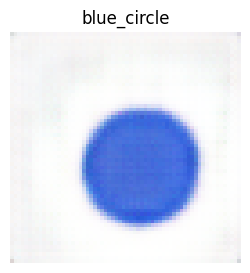

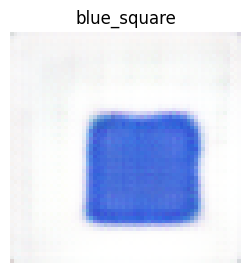

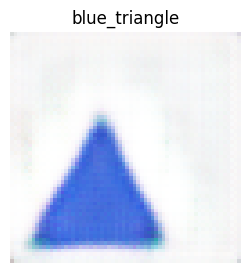

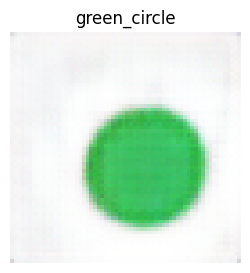

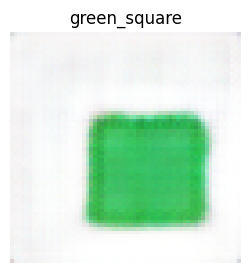

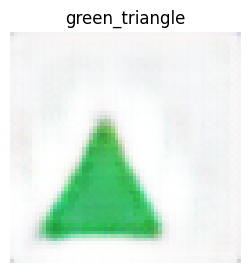

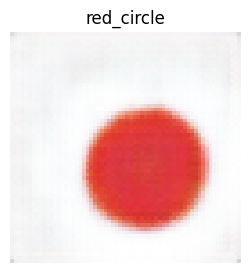

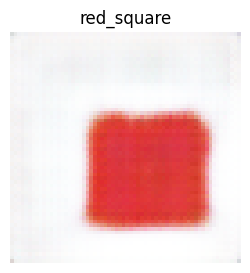

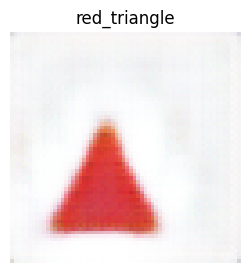

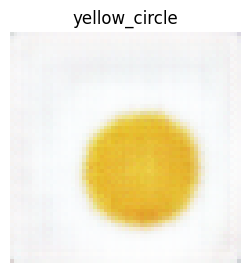

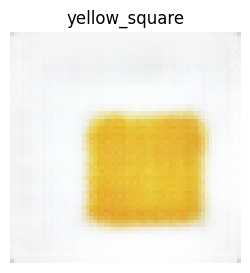

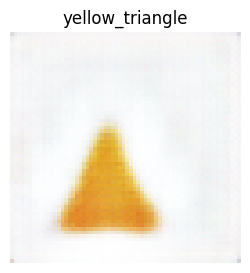

In [57]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

img_dir = Path("/kaggle/working/anime-ai-companion/n5_2_eval/images")

files = sorted(img_dir.glob("*.png"))

print("Images found:", len(files))

for p in files:
    img = Image.open(p)
    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis("off")
    plt.title(p.stem)
    plt.show()